In [3]:
import pandas as pd

# Try using the python engine and telling it to ignore 'bad' lines
df = pd.read_csv('/content/Amazon_Reviews.csv',
                 on_bad_lines='warn',
                 engine='python')

print(f"Successfully loaded {len(df)} rows.")

Successfully loaded 21214 rows.


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize
tfidf = TfidfVectorizer(max_features=5000)

# Convert text to numbers
X = tfidf.fit_transform(df['Review Text'].fillna(''))

In [5]:
import re

def clean_text(text):
    text = str(text).lower() # Convert to lowercase
    text = re.sub(r'\[.*?\]', '', text) # Remove text in brackets
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Remove URLs
    text = re.sub(r'<.*?>+', '', text) # Remove HTML tags
    text = re.sub(r'[^a-z0-9\s]', '', text) # Remove punctuation/special characters
    return text

# Apply cleaning to the 'Review Text' column
df['cleaned_review'] = df['Review Text'].apply(clean_text)

print("Text Cleaning Complete. Sample:")
print(df[['Review Text', 'cleaned_review']].head())

Text Cleaning Complete. Sample:
                                         Review Text  \
0  I registered on the website, tried to order a ...   
1  Had multiple orders one turned up and driver h...   
2  I informed these reprobates that I WOULD NOT B...   
3  I have bought from Amazon before and no proble...   
4  If I could give a lower rate I would! I cancel...   

                                      cleaned_review  
0  i registered on the website tried to order a l...  
1  had multiple orders one turned up and driver h...  
2  i informed these reprobates that i would not b...  
3  i have bought from amazon before and no proble...  
4  if i could give a lower rate i would i cancell...  


In [6]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    return " ".join([word for word in text.split() if word not in stop_words])

df['cleaned_review'] = df['cleaned_review'].apply(remove_stopwords)
print("Stopwords removed.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Stopwords removed.


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the vectorizer
tfidf = TfidfVectorizer(max_features=5000)

# Convert text into a numerical matrix (X)
X = tfidf.fit_transform(df['cleaned_review'])

print(f"Feature Matrix Shape: {X.shape}") # Should be (21214, 5000)

Feature Matrix Shape: (21214, 5000)


In [8]:
# Function to extract the rating number
def extract_rating(rating_str):
    try:
        # Extracts the first digit found in the string
        return int(re.search(r'\d', str(rating_str)).group())
    except:
        return 3 # Neutral if error

# Apply to the dataframe
df['rating_score'] = df['Rating'].apply(extract_rating)

# Create the binary label: 1 for Positive (4-5 stars), 0 for Negative (1-2 stars)
# We exclude 3-star reviews for a clearer classification model
df = df[df['rating_score'] != 3]
df['label'] = df['rating_score'].apply(lambda x: 1 if x > 3 else 0)

print("Labels created based on Ratings:")
print(df['label'].value_counts())

Labels created based on Ratings:
label
0    14350
1     5820
Name: count, dtype: int64


In [10]:
# 1. Filter the dataframe first (Removing 3-star reviews)
df_filtered = df[df['rating_score'] != 3].copy()

# 2. Create the labels (y) from the filtered data
y = df_filtered['label']

# 3. RE-RUN the Vectorizer on the filtered text only
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df_filtered['cleaned_review'])

# 4. Now split (they will both have 20,170 rows now)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X shape: {X.shape[0]}, y shape: {len(y)}")
print("Data successfully synchronized and split!")

X shape: 20170, y shape: 20170
Data successfully synchronized and split!


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Train Logistic Regression
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# 2. Train Random Forest (This might take a minute)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("--- Logistic Regression Accuracy ---")
print(accuracy_score(y_test, lr_preds))

print("\n--- Random Forest Accuracy ---")
print(accuracy_score(y_test, rf_preds))

--- Logistic Regression Accuracy ---
0.9315815567674764

--- Random Forest Accuracy ---
0.9048091224590976


--- Final Classification Report (Logistic Regression) ---
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      2870
           1       0.92      0.84      0.88      1164

    accuracy                           0.93      4034
   macro avg       0.93      0.90      0.91      4034
weighted avg       0.93      0.93      0.93      4034



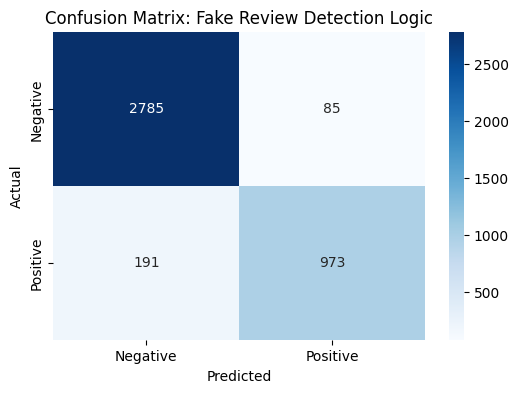

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate report for our best model (Logistic Regression)
print("--- Final Classification Report (Logistic Regression) ---")
print(classification_report(y_test, lr_preds))

# Plotting the Confusion Matrix
cm = confusion_matrix(y_test, lr_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Fake Review Detection Logic')
plt.show()

In [13]:
def predict_review(text):
    cleaned = remove_stopwords(clean_text(text))
    vectorized = tfidf.transform([cleaned])
    prediction = lr_model.predict(vectorized)
    return "Positive/Genuine" if prediction[0] == 1 else "Negative/Suspicious"

# Try it out!
print(predict_review("This product is amazing, I love it!"))
print(predict_review("Total waste of money, arrived broken and the seller is a scammer."))

Positive/Genuine
Negative/Suspicious
